In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("site_132450091.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [ ]:
cutoff_date = pd.to_datetime('2025-10-01')
train = df[df['Date'] < cutoff_date].copy()
test = df[df['Date'] >= cutoff_date].copy()

print(f"Taille Train: {len(train)} jours | Taille Test: {len(test)} jours")

Taille Train: 628 jours | Taille Test: 52 jours


In [ ]:
df_prophet = train[['Date', 'PM25']].rename(columns={'Date': 'ds', 'PM25': 'y'})

m = Prophet(yearly_seasonality=True, daily_seasonality=False)
m.fit(df_prophet)

future = pd.DataFrame({'ds': test['Date']})
forecast = m.predict(future)

test['Prophet_Pred'] = forecast['yhat'].values

In [ ]:
history = list(train['PM25'].values)
arima_preds = []

for t in range(len(test)):
    model = ARIMA(history, order=(7,1,2))
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    arima_preds.append(yhat)
    history.append(test['PM25'].iloc[t])

test['ARIMA_Pred'] = arima_preds


RÉSULTATS DU BENCHMARK STATISTIQUE (Oct/Nov 2025) :
 - MAE Prophet : 7.60
 - MAE ARIMA   : 4.13

'benchmark_prophet_arima.png' sauvegardé


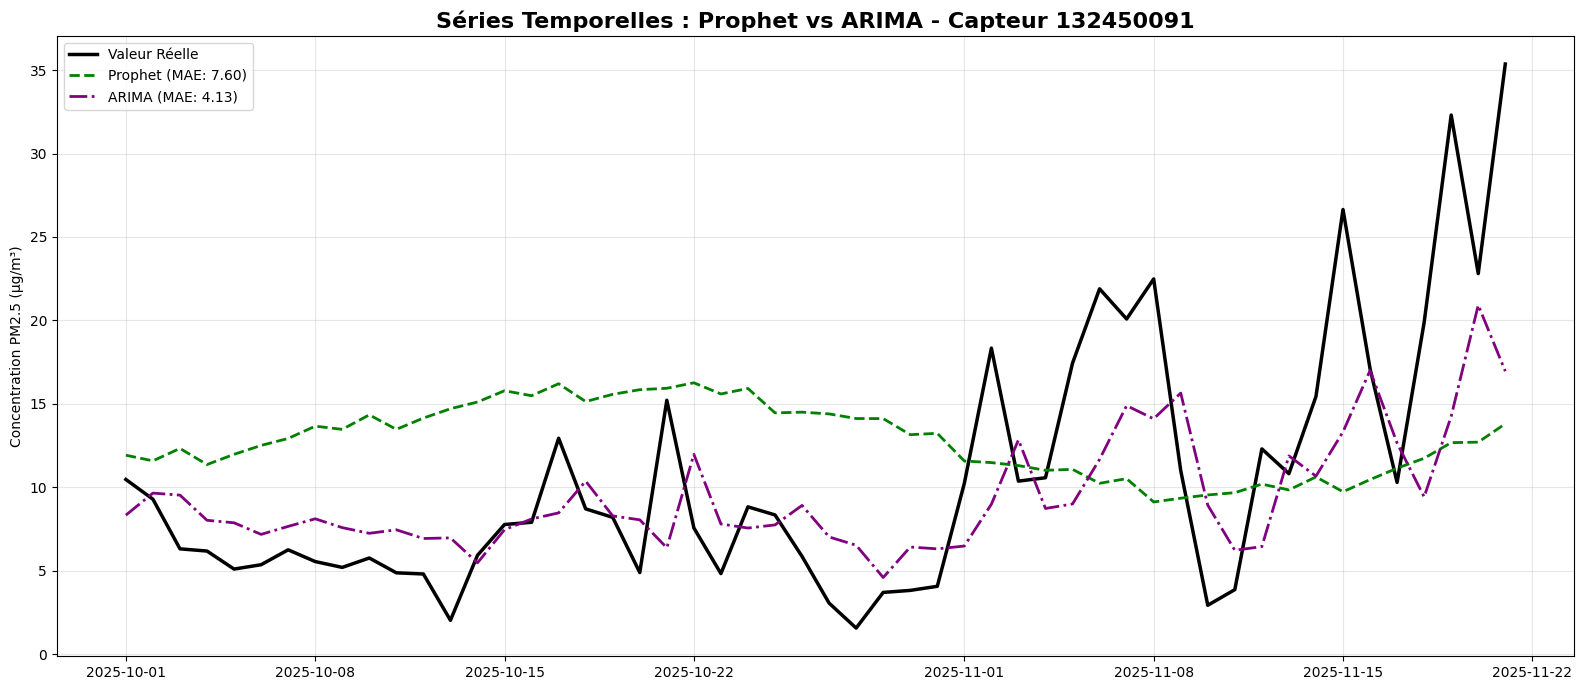

In [ ]:
mae_prophet = mean_absolute_error(test['PM25'], test['Prophet_Pred'])
mae_arima = mean_absolute_error(test['PM25'], test['ARIMA_Pred'])

print("\nRÉSULTATS DU BENCHMARK STATISTIQUE (Oct/Nov 2025) :")
print(f" - MAE Prophet : {mae_prophet:.2f}")
print(f" - MAE ARIMA   : {mae_arima:.2f}")

plt.figure(figsize=(16, 7))
plt.plot(test['Date'], test['PM25'], label='Valeur Réelle', color='black', linewidth=2.5)
plt.plot(test['Date'], test['Prophet_Pred'], label=f'Prophet (MAE: {mae_prophet:.2f})', color='green', linestyle='--', linewidth=2)
plt.plot(test['Date'], test['ARIMA_Pred'], label=f'ARIMA (MAE: {mae_arima:.2f})', color='purple', linestyle='-.', linewidth=2)

plt.title("Séries Temporelles : Prophet vs ARIMA - Capteur 132450091", fontsize=16, fontweight='bold')
plt.ylabel("Concentration PM2.5 (µg/m³)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("benchmark_prophet_arima.png", dpi=300)
print("\n'benchmark_prophet_arima.png' sauvegardé")